In [2]:
#Packages

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import plotly.graph_objects as go
import matplotlib as plt

from tabulate import tabulate
import timm
from timm.models.layers import to_2tuple

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from transformers import ViTForImageClassification

from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, classification_report

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 3
CLASS_NAMES = ["Tumor", "DCIS_1", "DCIS_2"]


# Loading in the test datasets
class CSVDataset(Dataset):
    def __init__(self, df, img_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_col = img_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row[self.img_col]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            img = self.transform(img)

        return img, label

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.7236, 0.6037, 0.8287],
        std=[0.1449, 0.1477, 0.0756]
    )
])

df = pd.read_csv("/kaggle/input/notebooks/smessenger/notebook957b6bbc9e/strategy1/master_labels_s1.csv")
test_df = df[df["split"] == "test"].reset_index(drop=True)

df_2 = pd.read_csv("/kaggle/input/notebooks/smessenger/notebook957b6bbc9e/strategy2/master_labels_s2.csv")
df_2["path_100_masked_new_path"] = df_2["path_100_masked"].str.replace(
    "/kaggle/working/masked_patches",
    "/kaggle/input/notebooks/smessenger/notebook957b6bbc9e/masked_patches")
test_df_2  = df_2[df_2["split"] == "test"].reset_index(drop=True)


test_ds_100 = CSVDataset(test_df, img_col="path_100", transform=transform)
test_ds_50  = CSVDataset(test_df, "path_50", transform=transform)
test_ds_m   = CSVDataset(test_df_2, "path_100_masked_new_path", transform=transform)

test_loader_100 = DataLoader(test_ds_100, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader_50 = DataLoader(test_ds_50, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader_m = DataLoader(test_ds_m, batch_size=32,shuffle=False,num_workers=2,pin_memory=True)

test_paths_100 = test_df["path_100"].tolist()
test_paths_50  = test_df["path_50"].tolist()
test_paths_m   = test_df_2["path_100_masked_new_path"].tolist()

def evaluate_model(model, loader, name, path_list):
    model.eval()

    preds_all = []
    labels_all = []
    wrong_paths = []
    paths_all = []
    idx = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)

            outputs = model(imgs)

            # For ViT need a different output:
            if hasattr(outputs, "logits"):
                logits = outputs.logits
            else:
                logits = outputs

            preds = logits.argmax(dim=1)
            
            preds_np = preds.cpu().numpy()
            labels_np = labels.numpy()

            for i in range(len(labels_np)):
                preds_all.append(preds_np[i])
                labels_all.append(labels_np[i])
                paths_all.append(path_list[idx])
                
                if preds_np[i] != labels_np[i]:
                    wrong_paths.append({
                        "image": path_list[idx],
                        "true": labels_np[i],
                        "pred": preds_np[i]
                    })
                idx += 1

            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.numpy())

    acc = accuracy_score(labels_all, preds_all)
    f1_macro = f1_score(labels_all, preds_all, average="macro")
    f1_per_class = f1_score(labels_all, preds_all, average=None)
    kappa = cohen_kappa_score(labels_all, preds_all)

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(f"F1 per class: {f1_per_class}")
    print(f"Kappa: {kappa:.4f}")
    

    return {
        "model": name,
        "accuracy": acc,
        "macro_f1": f1_macro,
        "kappa": kappa,
        "f1_Tumour": f1_per_class[0],
        "f1_DCIS_1": f1_per_class[1],
        "f1_DCIS_2": f1_per_class[2],

        # For McNemar later
        "preds": preds_all,
        "labels": labels_all,

        # For Error later
        "wrong": wrong_paths
    }

# Defining helper funcitons to load in the models

def load_resnet(path):
    model = models.resnet50(weights=None)

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(2048, NUM_CLASSES)
    )

    state = torch.load(path, map_location=DEVICE)
    model.load_state_dict(state)

    return model.to(DEVICE)


def load_vit(path):
    model = ViTForImageClassification.from_pretrained(path).to(DEVICE)
    return model.to(DEVICE)

# Ctranspath is slightly more complicated to load in
class ConvStem(nn.Module):
    def __init__(self, img_size=224, patch_size=4, in_chans=3,
                 embed_dim=768, norm_layer=None, flatten=True):
        super().__init__()
        assert patch_size == 4
        assert embed_dim % 8 == 0
        img_size   = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        self.img_size    = img_size
        self.patch_size  = patch_size
        self.grid_size   = (img_size[0] // patch_size[0],
                            img_size[1] // patch_size[1])
        self.num_patches = self.grid_size[0] * self.grid_size[1]
        self.flatten     = flatten
        stem = []
        input_dim, output_dim = 3, embed_dim // 8
        for _ in range(2):
            stem += [
                nn.Conv2d(input_dim, output_dim,
                          kernel_size=3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(output_dim),
                nn.ReLU(inplace=True),
            ]
            input_dim  = output_dim
            output_dim = output_dim * 2
        stem.append(nn.Conv2d(input_dim, embed_dim, kernel_size=1))
        self.proj = nn.Sequential(*stem)
        self.norm = norm_layer(embed_dim) if norm_layer else nn.Identity()

    def forward(self, x):
        x = self.proj(x)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        return x

def ctranspath():
    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False)
    model.head = nn.Identity()
    embed_dim = model.patch_embed.proj.out_channels
    model.patch_embed = ConvStem(
        img_size=224, patch_size=4, in_chans=3,
        embed_dim=embed_dim, norm_layer=nn.LayerNorm, flatten=True
    )
    return model

class CTranspathClassifier(nn.Module):
    def __init__(self, backbone, num_classes=3, feat_dim=768, dropout=0.5):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(dropout * 0.6),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        if features.dim() == 4:
            features = features.mean(dim=(1, 2))
        elif features.dim() == 3:
            features = features.mean(dim=1)
        return self.classifier(features)

def load_ctranspath(path):
    backbone = ctranspath() 
    model    = CTranspathClassifier(backbone, num_classes=NUM_CLASSES)
    state = torch.load(path, map_location=DEVICE)
    model.load_state_dict(state, strict=False)

    return model.to(DEVICE)


# Paths to the trained model files
RESNET_PATH_100_1 = "/kaggle/input/datasets/smessenger/resnet-new/cnn_best_100px.pth"
RESNET_PATH_50_1 = "/kaggle/input/datasets/smessenger/resnet-new/cnn_best_50px.pth"
RESNET_PATH_100_2 = "/kaggle/input/datasets/smessenger/resnet-new/cnn_best_masked.pth"

VIT_PATH_100_1 = "/kaggle/input/notebooks/smessenger/hyperparameter-tuning-final-models/ViT_100_1"
VIT_PATH_50_1 = "/kaggle/input/notebooks/smessenger/hyperparameter-tuning-final-models/ViT_50_1"
VIT_PATH_100_2 = "/kaggle/input/notebooks/smessenger/hyperparameter-tuning-final-models/ViT_100_2"

CTRANS_PATH_100_1 = "/kaggle/input/datasets/smessenger/ctranspath-pth/100px_best_model.pth"
CTRANS_PATH_50_1 = "/kaggle/input/datasets/smessenger/ctranspath-pth/50px_best_model.pth"
CTRANS_PATH_100_2 = "/kaggle/input/datasets/smessenger/ctranspath-pth/masked_best_model.pth"


# Loading the models
resnet_100_1 = load_resnet(RESNET_PATH_100_1)
resnet_50_1 = load_resnet(RESNET_PATH_50_1)
resnet_100_2 = load_resnet(RESNET_PATH_100_2)

vit_100_1 = load_vit(VIT_PATH_100_1)
vit_50_1 = load_vit(VIT_PATH_50_1)
vit_100_2 = load_vit(VIT_PATH_100_2)

ctrans_model_100_1 = load_ctranspath(CTRANS_PATH_100_1)
ctrans_model_50_1 = load_ctranspath(CTRANS_PATH_50_1) 
ctrans_model_100_2 = load_ctranspath(CTRANS_PATH_100_2) 

# Getting their results on the test set
results = []

results.append(evaluate_model(resnet_100_1, test_loader_100, "ResNet-50 - 100px", test_paths_100))
results.append(evaluate_model(resnet_50_1, test_loader_50, "ResNet-50 - 50px", test_paths_50))
results.append(evaluate_model(resnet_100_2, test_loader_m, "ResNet-50 - Masked", test_paths_m))

results.append(evaluate_model(vit_100_1, test_loader_100, "ViT - 100px", test_paths_100))
results.append(evaluate_model(vit_50_1, test_loader_50, "ViT - 50px", test_paths_50))
results.append(evaluate_model(vit_100_2, test_loader_m, "ViT - Masked", test_paths_m))

results.append(evaluate_model(ctrans_model_100_1, test_loader_100, "CTransPath - 100px", test_paths_100))
results.append(evaluate_model(ctrans_model_50_1, test_loader_50, "CTransPath - 50px", test_paths_50))
results.append(evaluate_model(ctrans_model_100_2, test_loader_m, "CTransPath - Masked", test_paths_m))

results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison.csv", index=False)

#print("\nFINAL MODEL COMPARISON")
#print(df)

# Making evaluation metrics table
# Load results
df = results_df.copy()

# Formatting
df_clean = df.drop(columns=['preds', 'labels'], errors='ignore')

def split_model(x):
    # "ViT - 100 S1" → ("ViT", "100 S1")
    parts = x.split(" - ")
    model = parts[0]
    setting = parts[1] if len(parts) > 1 else "Unknown"
    return pd.Series([model, setting])

df_clean[["Model", "Spatial Context"]] = df_clean["model"].apply(split_model)


cols = [
    "Model",
    "Spatial Context",
    "accuracy",
    "macro_f1",
    "kappa",
    "f1_Tumour",
    "f1_DCIS_1",
    "f1_DCIS_2"
]

table_df = df_clean[[c for c in cols if c in df_clean.columns]].copy()

table_df.columns = (
    table_df.columns
    .str.replace("_", " ", regex=False)
    .str.title()
)
table_df.columns = [
    col.replace("Dcis", "DCIS")
       .replace("F1", "F1")
    for col in table_df.columns
]
metric_cols = [
    "Accuracy",
    "Macro F1",
    "Kappa",
    "F1 Tumour",
    "F1 DCIS 1",
    "F1 DCIS 2"
]

table_df[metric_cols] *= 100

table_df = table_df.round(4)

# Print clean table
print("\nFINAL MODEL COMPARISON\n")
print(tabulate(table_df, headers='keys', tablefmt='grid', showindex=False))

# Save outputs
table_df.to_csv('model_comparison_clean.csv', index=False)
table_df.to_html('model_comparison.html', float_format="%.3f",sparsify=True, notebook=True, index=False)
pivot = table_df.set_index(["Model", "Spatial Context"])
pivot.to_latex(float_format="%.1f", multicolumn=False, multirow=True, column_format='llcccccc')

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


ResNet-50 - 100px
Accuracy: 0.9201
Macro F1: 0.9152
F1 per class: [0.94674556 0.9284141  0.87055838]
Kappa: 0.8784

ResNet-50 - 50px
Accuracy: 0.6210
Macro F1: 0.5776
F1 per class: [0.72251656 0.46846847 0.54185893]
Kappa: 0.4012

ResNet-50 - Masked
Accuracy: 0.8044
Macro F1: 0.8050
F1 per class: [0.81902718 0.83074935 0.76512227]
Kappa: 0.7067

ViT - 100px
Accuracy: 0.9427
Macro F1: 0.9386
F1 per class: [0.96680851 0.94495913 0.90400509]
Kappa: 0.9128

ViT - 50px
Accuracy: 0.9073
Macro F1: 0.9024
F1 per class: [0.9346991  0.91603053 0.85641999]
Kappa: 0.8590

ViT - Masked
Accuracy: 0.8120
Macro F1: 0.8115
F1 per class: [0.83444149 0.84186352 0.75815217]
Kappa: 0.7180

CTransPath - 100px
Accuracy: 0.9524
Macro F1: 0.9490
F1 per class: [0.97239915 0.95419847 0.92033142]
Kappa: 0.9276

CTransPath - 50px
Accuracy: 0.9371
Macro F1: 0.9322
F1 per class: [0.96352841 0.94123989 0.89190939]
Kappa: 0.9043

CTransPath - Masked
Accuracy: 0.8936
Macro F1: 0.8931
F1 per class: [0.91936595 0.905519

'\\begin{tabular}{llcccccc}\n\\toprule\n &  & Accuracy & Macro F1 & Kappa & F1 Tumour & F1 DCIS 1 & F1 DCIS 2 \\\\\nModel & Spatial Context &  &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{3}{*}{ResNet-50} & 100px & 92.0 & 91.5 & 87.8 & 94.7 & 92.8 & 87.1 \\\\\n & 50px & 62.1 & 57.8 & 40.1 & 72.3 & 46.8 & 54.2 \\\\\n & Masked & 80.4 & 80.5 & 70.7 & 81.9 & 83.1 & 76.5 \\\\\n\\cline{1-8}\n\\multirow[t]{3}{*}{ViT} & 100px & 94.3 & 93.9 & 91.3 & 96.7 & 94.5 & 90.4 \\\\\n & 50px & 90.7 & 90.2 & 85.9 & 93.5 & 91.6 & 85.6 \\\\\n & Masked & 81.2 & 81.1 & 71.8 & 83.4 & 84.2 & 75.8 \\\\\n\\cline{1-8}\n\\multirow[t]{3}{*}{CTransPath} & 100px & 95.2 & 94.9 & 92.8 & 97.2 & 95.4 & 92.0 \\\\\n & 50px & 93.7 & 93.2 & 90.4 & 96.4 & 94.1 & 89.2 \\\\\n & Masked & 89.4 & 89.3 & 84.0 & 91.9 & 90.6 & 85.4 \\\\\n\\cline{1-8}\n\\bottomrule\n\\end{tabular}\n'

In [3]:
# McNemar's Test
import ast
from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(y_true, pred_a, pred_b):
    pred_a = np.array(pred_a)
    pred_b = np.array(pred_b)
    y_true = np.array(y_true)

    a_correct = pred_a == y_true
    b_correct = pred_b == y_true

    # contingency table
    both_correct = np.sum(a_correct & b_correct)
    a_only = np.sum(a_correct & ~b_correct)
    b_only = np.sum(~a_correct & b_correct)
    both_wrong = np.sum(~a_correct & ~b_correct)

    table = [[both_correct, a_only],
             [b_only, both_wrong]]

    result = mcnemar(table, exact=False, correction=True)

    return {
        "table": table,
        "statistic": result.statistic,
        "p_value": result.pvalue
    }
all_results = {
    "ResNet-100-S1": evaluate_model(resnet_100_1, test_loader_100, "ResNet-50 - 100 S1", test_paths_100),
    "ResNet-50-S1": evaluate_model(resnet_50_1, test_loader_50, "ResNet-50 - 50 S1", test_paths_50),
    "ResNet-100-S2": evaluate_model(resnet_100_2, test_loader_m, "ResNet-50 - 100 S2", test_paths_m),
    "ViT-100-S1": evaluate_model(vit_100_1, test_loader_100, "ViT - 100 S1", test_paths_100),
    "ViT-50-S1": evaluate_model(vit_50_1, test_loader_50, "ViT - 50 S1", test_paths_50),
    "ViT-100-S2": evaluate_model(vit_100_2, test_loader_m, "ViT - 100 S2", test_paths_m),
    "CTrans-100-S1": evaluate_model(ctrans_model_100_1, test_loader_100, "CTransPath - 100 S1", test_paths_100),
    "CTrans-50-S1": evaluate_model(ctrans_model_50_1, test_loader_50, "CTransPath - 50 S1", test_paths_50),
    "CTrans-100-S2": evaluate_model(ctrans_model_100_2, test_loader_m, "CTransPath - 100 S2", test_paths_m),
}


ResNet-50 - 100 S1
Accuracy: 0.9201
Macro F1: 0.9152
F1 per class: [0.94674556 0.9284141  0.87055838]
Kappa: 0.8784

ResNet-50 - 50 S1
Accuracy: 0.6210
Macro F1: 0.5776
F1 per class: [0.72251656 0.46846847 0.54185893]
Kappa: 0.4012

ResNet-50 - 100 S2
Accuracy: 0.8044
Macro F1: 0.8050
F1 per class: [0.81902718 0.83074935 0.76512227]
Kappa: 0.7067

ViT - 100 S1
Accuracy: 0.9427
Macro F1: 0.9386
F1 per class: [0.96680851 0.94495913 0.90400509]
Kappa: 0.9128

ViT - 50 S1
Accuracy: 0.9073
Macro F1: 0.9024
F1 per class: [0.9346991  0.91603053 0.85641999]
Kappa: 0.8590

ViT - 100 S2
Accuracy: 0.8120
Macro F1: 0.8115
F1 per class: [0.83444149 0.84186352 0.75815217]
Kappa: 0.7180

CTransPath - 100 S1
Accuracy: 0.9524
Macro F1: 0.9490
F1 per class: [0.97239915 0.95419847 0.92033142]
Kappa: 0.9276

CTransPath - 50 S1
Accuracy: 0.9371
Macro F1: 0.9322
F1 per class: [0.96352841 0.94123989 0.89190939]
Kappa: 0.9043

CTransPath - 100 S2
Accuracy: 0.8936
Macro F1: 0.8931
F1 per class: [0.91936595 0.

['ResNet-100-S1', 'ResNet-50-S1', 'ViT-100-S1', 'ViT-50-S1', 'CTrans-100-S1', 'CTrans-50-S1']
          Model A        Model B   statistic  p_value
0   ResNet-100-S1   ResNet-50-S1 1491.360020 0.000000
5    ResNet-50-S1     ViT-100-S1 1669.688596 0.000000
7    ResNet-50-S1  CTrans-100-S1 1793.219428 0.000000
8    ResNet-50-S1   CTrans-50-S1 1625.128193 0.000000
6    ResNet-50-S1      ViT-50-S1 1314.248547 0.000000
12      ViT-50-S1  CTrans-100-S1  199.645833 0.000000
3   ResNet-100-S1  CTrans-100-S1  130.629771 0.000000
9      ViT-100-S1      ViT-50-S1  114.469444 0.000000
13      ViT-50-S1   CTrans-50-S1   86.002941 0.000000
1   ResNet-100-S1     ViT-100-S1   56.602041 0.000000
14  CTrans-100-S1   CTrans-50-S1   48.519231 0.000000
4   ResNet-100-S1   CTrans-50-S1   29.588050 0.000000
10     ViT-100-S1  CTrans-100-S1   25.208333 0.000001
2   ResNet-100-S1      ViT-50-S1   11.242616 0.000799
11     ViT-100-S1   CTrans-50-S1    5.111702 0.023765


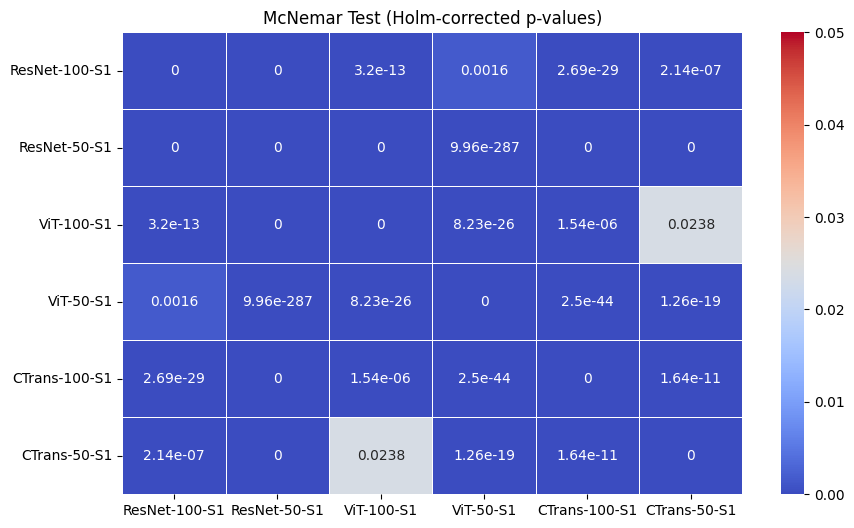

In [5]:
model_names = ['ResNet-100-S1', 'ResNet-50-S1', 'ViT-100-S1', 'ViT-50-S1', 'CTrans-100-S1', 'CTrans-50-S1']
pd.set_option('display.float_format', '{:.6f}'.format)
print(model_names)
from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
mcnemar_results = []

for model_a, model_b in combinations(model_names, 2):

    res_a = all_results[model_a]
    res_b = all_results[model_b]

    test = mcnemar_test(
        res_a["labels"],
        res_a["preds"],
        res_b["preds"]
    )

    mcnemar_results.append({
        "Model A": model_a,
        "Model B": model_b,
        "statistic": test["statistic"],
        "p_value": test["p_value"]
    })

mcnemar_df = pd.DataFrame(mcnemar_results)
mcnemar_df = mcnemar_df.sort_values("p_value")
print(mcnemar_df)
mcnemar_df.to_csv("mcnemar_results.csv", index=False)

reject, p_corrected, _, _ = multipletests(
    mcnemar_df["p_value"],
    method="holm"
)

mcnemar_df["p_corrected"] = p_corrected
mcnemar_df["significant_holm"] = reject

matrix = pd.DataFrame(
    np.zeros((len(model_names), len(model_names))),
    index=model_names,
    columns=model_names
)

for _, row in mcnemar_df.iterrows():
    a, b = row["Model A"], row["Model B"]
    p = row["p_corrected"]

    matrix.loc[a, b] = p
    matrix.loc[b, a] = p

np.fill_diagonal(matrix.values, 0)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".3g",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=0,
    vmax=0.05  
)

plt.title("McNemar Test (Holm-corrected p-values)")
plt.savefig("McNemar.png")
plt.show()


In [8]:
# Generating the Classification Error Images 
all_wrong = []

for row in results:
    model_name = row["model"]

    for err in row["wrong"]:
        all_wrong.append({
            "model": model_name,
            "image": err["image"],
            "true": err["true"],
            "pred": err["pred"]
        })

wrong_df = pd.DataFrame(all_wrong)
counts = wrong_df.groupby("image")["model"].nunique()
common_wrong = wrong_df[wrong_df["image"].isin(counts[counts == 9].index)]

ctrans_models = [m for m in model_names if "CTransPath" in m]
vit_models = [m for m in model_names if "ViT" in m]

ctrans_wrong = wrong_df[wrong_df["model"].isin(ctrans_models)]
vit_wrong = wrong_df[wrong_df["model"].isin(vit_models)]

ctrans_only = ctrans_wrong[~ctrans_wrong["image"].isin(vit_wrong["image"])]

import matplotlib.pyplot as plt
from PIL import Image

def show_grid(df, title, n=9):

    if len(df) == 0:
        print(f"No images found for: {title}")
        return

    df = df.sample(min(n, len(df)))

    plt.figure(figsize=(10,10))

    for i, row in enumerate(df.itertuples()):

        try:
            img = Image.open(row.image)
        except FileNotFoundError:
            print(f"Missing file: {row.image}")
            continue

        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.title(f"T:{row.true} P:{row.pred}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

#show_grid(common_wrong, "Errors Shared Across All Models")
#show_grid(ctrans_only, "CTransPath Unique Errors")

No images found for: Errors Shared Across All Models
No images found for: CTransPath Unique Errors
